# 04 — District attribution: POC

Every districting method this project has, run on one network, scored the same way, and
written out in the `districts.yml` schema the rest of the pipeline consumes.

**Methods.** `spectral` partitions the network's own graph under a composite edge affinity
(resistance / elevation / valve-cut / optional measured coupling — the dials in §3).
`girvan_newman`, `fast_greedy` and `walktrap` are community detection on bare topology, after
Shekofteh, Yousefi-Khoshqalb & Piratla, *Water Resources Management* 37:5007–5022 (2023).
`external` adopts an existing partition so it is scored on identical footing.

**Everything after the partition is shared** — naming, contiguity/balance/elevation report,
boundary-pipe accounting, the optional Phase-3 optimisation (exhaustive or NSGA-II), the
sanity suite, and the writer. That is what makes the comparison in §6 legitimate rather than
five methods each grading their own homework.

**Scope.** Districts only. No sensors, no drift, no federated training.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..\\..\\..\\src').resolve()))
import districting as dst

warnings.simplefilter('ignore')
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 80)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 8})

NETWORK = 'ky7'
K = 5                                   # paper Table 2 for D-Town
SEED = 3
OUT_DIR = Path('out'); OUT_DIR.mkdir(exist_ok=True)

BUNDLE = dst.find_bundle(NETWORK)       # walks up to data/01_raw/<network>/
wn = dst.yaml_io.load_network(BUNDLE / 'network.inp')
g = dst.build_graph(wn)

print('bundle  ', BUNDLE)
print('graph   %d nodes, %d edges, components %s'
      % (g.number_of_nodes(), g.number_of_edges(), dst.component_report(g)['sizes']))
print('nodes   %d junctions (%d consumers), %d tanks, %d reservoirs'
      % (len(wn.junction_name_list), len(dst.consumer_nodes(wn)),
         len(wn.tank_name_list), len(wn.reservoir_name_list)))
print('links   %d pipes, %d pumps, %d valves'
      % (len(wn.pipe_name_list), len(wn.pump_name_list), len(wn.valve_name_list)))
print('elev    %s' % dst.check_elevation_informative(g))

bundle   C:\Users\arthu\USPy\10_Mestrado\fedWater\data\01_raw\ky7
graph   485 nodes, 601 edges, components [485]
nodes   481 junctions (463 consumers), 3 tanks, 1 reservoirs
links   603 pipes, 1 pumps, 0 valves
elev    {'n_values': 481, 'span_m': 70.00884144000001, 'std_m': 10.585076898353364, 'informative': True}


## 1. What the network actually contains

The hydraulic components are inventoried up front because they decide things a node plot
hides: which districts own a source, where a pump sits relative to a cut, which valves are
regulating (PRV/PSV/PBV — these make coupling directional) versus throttling. They are
overlaid on every map from §4 onward.

In [2]:
assets = dst.hydraulic_assets(wn)
display(assets.groupby(['kind', 'subtype']).size().rename('n').to_frame())
display(assets.head(12))

n
kind      subtype              
pump      POWER               1
reservoir reservoir           1
tank      tank (17.7 m diam)  1
          tank (19.8 m diam)  1
          tank (23.8 m diam)  1

,name,kind,subtype,x,y
0,R-1,reservoir,reservoir,4248378.00,3541041.0
1,T-1,tank,tank (19.8 m diam),4289578.00,3572147.0
2,T-2,tank,tank (23.8 m diam),4297624.00,3573739.0
3,T-3,tank,tank (17.7 m diam),4300380.00,3575141.0
4,~@Pump-1,pump,POWER,4248205.67,3541635.0


## 2. Reference partition, and the one honest use of AMI/ARI

D-Town ships a real utility districting decision in its `[TAGS]` section: 5 DMAs, chosen by
an engineer, not by any algorithm here. That makes it the one external, non-synthetic ground
truth available — and the **only** partition in this corpus that AMI/ARI may be quoted
against.

Scoring a method against a `districts.yml` that some earlier run of this same code produced
measures self-consistency, not correctness. On any network without published tags, the
agreement columns in §6 are meaningless and are simply absent.

The tag partition doubles as the `external` method's input, so the shipped decision goes
through Phase 2 and 3 on exactly the same footing as the discovered ones.

In [3]:
REFERENCE = dst.metrics.published_dma_tags(wn)          # {} on a network without [TAGS]
REFERENCE_MAPPING = {d: sorted(n for n, v in REFERENCE.items() if v == d)
                     for d in sorted(set(REFERENCE.values()))}

if REFERENCE:
    print('published DMAs: %d junctions across %d DMAs  -> AMI/ARI are meaningful here'
          % (len(REFERENCE), len(REFERENCE_MAPPING)))
    display(pd.Series({d: len(v) for d, v in REFERENCE_MAPPING.items()}, name='n_junctions')
            .to_frame().T)
else:
    print('no [TAGS] on this network -- external method and agreement columns are skipped')

no [TAGS] on this network -- external method and agreement columns are skipped


## 3. Run every method

One config, one shared graph, five runs. The dials (`weights`) apply to `spectral` only; the
community methods are topology-only by construction, which is the paper's stated novelty —
the layout is decoupled from hydraulic criteria and survives a change of criteria unchanged.

**Post-processing defaults differ by family, on purpose.** Contiguity repair and size
rebalancing are on for `spectral`, where contiguous comparably-sized clients are the whole
point, and off for the community methods, which are reproduced as published rather than
quietly improved. Contiguity is *measured* either way. Both are overridable
(`repair=True/False`, `balance_target='count'|'demand'|None`).

**Phase 3** minimises the number of open boundary pipes (Eq. 1) and their total length
(Eq. 2) under the pressure/velocity constraint (Eq. 3). `optimizer='auto'` enumerates exactly
when the search space fits `budget` and falls back to NSGA-II otherwise; set
`optimizer='nsga2'` to force the paper's own optimiser, or `'none'` to skip Phase 3 and keep
the boundary accounting only.

In [4]:
cfg = dst.DistrictingConfig(
    k=K, seed=SEED,
    weights=dst.DistrictingWeights(w_resistance=1.0, w_elevation=1.0,
                                   w_valve_cut=1.0, w_coupling=0.0),
    criteria=dst.HydraulicCriteria(min_pressure_m=14, max_velocity_ms=3),  # paper Table 2
    optimizer='auto', budget=40000,
    nsga2=dict(pop_size=60, generations=25, seed=0),   # paper used 400 x 2000
)

results = dst.run_all(wn, cfg, network=NETWORK,
                      mapping=REFERENCE_MAPPING or None,
                      reference=REFERENCE or None)

  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


spectral       k=5  contiguous=True   imbalance=7.33  boundary=50
girvan_newman  k=5  contiguous=True   imbalance=6.09  boundary=13
fast_greedy    k=5  contiguous=True   imbalance=3.95  boundary=19
walktrap       k=5  contiguous=True   imbalance=80.60  boundary=4


In [5]:
# Force the paper's own optimiser on one method, to check the exact front is not
# something only the enumerator can reach. Same partition, different backend.
from dataclasses import replace

check = dst.run(wn, replace(cfg, method='girvan_newman', optimizer='nsga2'),
                network=NETWORK, graph=g)
exact = results['girvan_newman']
print('exhaustive front:', [(f['NO'], round(f['LO'], 1)) for f in exact.optimization['front']])
print('NSGA-II front:   ', [(f['NO'], round(f['LO'], 1)) for f in check.optimization['front']],
      ' (%d evaluations vs %d)' % (check.optimization['evaluations'],
                                   exact.optimization['evaluations']))

exhaustive front: []
NSGA-II front:    []  (1 evaluations vs 1)


### Is each community partition a unique answer?

`fast_greedy` is a greedy agglomeration, so near-ties in its merge sequence are resolved by
vertex index and send it to a different local optimum. Re-indexing the *same* graph
lexicographically instead of in `.inp` declaration order is a pure tie-break change, and the
table below says what it costs.

On D-Town it costs almost nothing in modularity and a great deal in interpretation: the two
orderings score 0.7729 and 0.7714 — equally good — while agreeing about only 78% of nodes,
and the lexical one drags `fast_greedy` to AMI 0.94 against `girvan_newman`, making two
distinct methods look like one. Vertex order is therefore pinned to the network's own, which
reproduces the reference implementation bit for bit. Where `order_sensitive` is True, read
that method's row as *one of several comparably modular answers*, not as its unique output.

In [6]:
display(pd.DataFrame([dst.partition.order_sensitivity(g, wn, K, m)
                      for m in ('girvan_newman', 'fast_greedy', 'walktrap')]))

,method,ami_between_orders,modularity_declared,modularity_lexical,modularity_gap,order_sensitive
0,girvan_newman,1.0000,0.6707,0.6707,0.00000,False
1,fast_greedy,0.6406,0.7370,0.7517,0.01471,True
2,walktrap,1.0000,0.1880,0.1880,0.00000,False


## 4. Visualisation A — the dials, live

Move a slider, see the partition and its metrics. The factor weights apply to `spectral`;
selecting a community method is still useful for `k`, but the notebook says so rather than
letting dead dials look broken. The elevation dial warns when the network is too flat for it
to do anything, and the coupling dial is disabled outright unless a measured coupling matrix
was supplied.

In [7]:
coupling = dst.coupling.load_coupling(NETWORK)     # None unless an interventional map exists
_ = dst.plots.interactive_districting(wn, network=NETWORK, reference=REFERENCE or None,
                                      coupling=coupling, k=K)

interactive(children=(Dropdown(description='method', options=('spectral', 'girvan_newman', 'fast_greedy', 'wal…

## 5. Visualisation B — compare two methods

Pick any two. The second partition is recoloured to maximum overlap with the first, so the
eye reads the *difference in boundaries* rather than an arbitrary colour permutation; the
third panel marks every node the two disagree about. Hydraulic components are overlaid on all
three, and boundary pipes are drawn green (flow meter, stays open) or red (gate valve, closed)
wherever Phase 3 produced a layout.

In [8]:
_ = dst.plots.interactive_comparison(wn, results, default=('spectral', 'girvan_newman'))

interactive(children=(Dropdown(description='method_a', options=('spectral', 'girvan_newman', 'fast_greedy', 'w…

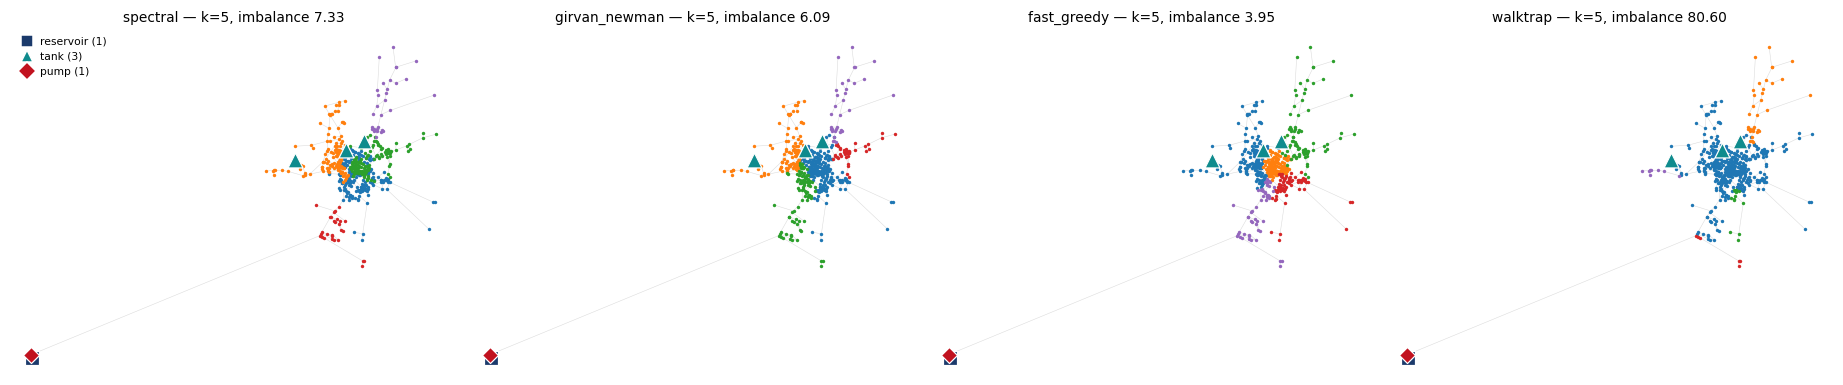

In [9]:
# Static version for export, and every method's own map
fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4.4))
for ax, (name, r) in zip(axes, results.items()):
    dst.plots.plot_districts(wn, r.labels, ax,
                             '%s — k=%d, imbalance %.2f'
                             % (name, r.k, r.report['balance']['count_imbalance']),
                             status=r.status if r.best else None, node_size=5,
                             legend=(ax is axes[0]))
fig.tight_layout(); plt.show()

## 6. Sanity checks

Assertions the output must survive before anything downstream reads it, in four blocks:
the `districts.yml` **schema contract** (junctions covered exactly once, assets recorded and
never duplicated into `districts`), **partition properties** (contiguity, `k` achieved, no
empty district, every node labelled), **reproducibility** (same config, same labels), and
**hydraulics** where Phase 3 ran (baseline feasible, front exact rather than budget-truncated,
forced-open pipes actually open).

A failing row is not automatically fatal — the rebalance-tolerance row can legitimately fail
when every movable boundary node is an articulation point of its own district — but each one
carries the detail needed to decide, rather than only a verdict.

In [10]:
checks = {}
for name, r in results.items():
    sc = dst.sanity_check(wn, r, mapping=REFERENCE_MAPPING or None)
    checks[name] = sc
    print('%-14s %2d/%2d pass' % (name, sc.ok.sum(), len(sc)))

failures = pd.concat([sc.assign(method=m) for m, sc in checks.items()]).query('not ok')
display(failures[['method', 'check', 'detail']].reset_index(drop=True)
        if len(failures) else pd.DataFrame({'note': ['every check passed for every method']}))

spectral       17/19 pass
girvan_newman  17/18 pass
fast_greedy    17/18 pass
walktrap       17/18 pass


,method,check,detail
0,spectral,rebalancing reached its tolerance,imbalance 12.14 -> 7.33 in 101 move(s) — no fu...
1,spectral,intact network meets the stated criteria,"baseline min pressure -8.56 m, max velocity 2...."
2,girvan_newman,intact network meets the stated criteria,"baseline min pressure -8.56 m, max velocity 2...."
3,fast_greedy,intact network meets the stated criteria,"baseline min pressure -8.56 m, max velocity 2...."
4,walktrap,intact network meets the stated criteria,"baseline min pressure -8.56 m, max velocity 2...."


In [11]:
display(checks['spectral'])

,check,ok,detail
0,schema: districts cover every junction,True,ok
1,schema: districts contain only junctions,True,ok
2,schema: no junction listed twice,True,ok
3,schema: no empty district,True,ok
4,schema: assets cover every tank/reservoir,True,ok
5,schema: assets contain only tanks/reservoirs,True,ok
6,schema: no asset listed twice,True,ok
7,schema: assets never appear under districts,True,ok
8,every district is contiguous,True,ok
9,k achieved equals k requested,True,"requested 5, got 5"


## 7. Summary

Three blocks of columns: what the partition **is** (districts, sizes, imbalance), what it
**costs** (boundary links, flow meters, gate valves, open length), and how it **scores**
(contiguity, modularity, structural coupling ratio, elevation separation, agreement).

Read it knowing whose home ground each metric is. Modularity is what the community methods
optimise, so they should win it; the spectral method is not trying to. `size_imbalance` is
not in the paper's objective at all. A column that needed a Phase-3 run it did not get comes
back `NaN`, never `0` — "no meters" and "never counted the meters" are different statements.

In [12]:
summary = dst.compare(results)
display(summary.set_index('method').T)
summary.to_csv(OUT_DIR / ('%s__summary.csv' % NETWORK), index=False)

method,spectral,girvan_newman,fast_greedy,walktrap
network,ky7,ky7,ky7,ky7
k_requested,5,5,5,5
n_districts,5,5,5,5
min_junctions,30,33,55,8
max_junctions,161,204,158,418
size_imbalance,7.33,6.09,3.95,80.6
demand_imbalance,4.73,4.24,2.78,50.36
all_contiguous,True,True,True,True
n_fragments_repaired,0,0,0,0
rebalance_moves,101.0,NaN,NaN,NaN


In [13]:
if REFERENCE:
    print('agreement against the published DMA partition (valid on this network only):')
    display(summary[['method', 'ami_vs_reference', 'ari_vs_reference',
                     'size_imbalance', 'modularity']]
            .sort_values('ami_vs_reference', ascending=False).reset_index(drop=True))
    print("external == 1.0 by construction: it IS the reference, so that row is the "
          "identity check on the scoring path, not a result.")

## 8. Outputs

One `districts.yml` per method, in the schema the pipeline consumes: junctions partitioning
the junction set exactly under `districts`, tanks and reservoirs under `assets`. The split is
load-bearing — a tank listed under `districts` would break portfolio building and make every
tank feed read as an inter-district boundary pipe.

Each file is read back and re-validated after writing, so a round-trip failure surfaces here
rather than three stages downstream. The boundary/status table is written alongside: it is
where the flow meters are, which is the hand-off to sensor placement.

In [14]:
written = []
for name, r in results.items():
    slug = '%s__%s__k%d' % (NETWORK, name, r.k)
    path = r.write_yml(OUT_DIR / (slug + '__districts.yml'), wn)
    roundtrip = dst.validate_districts(wn, dst.read_districts_yml(path))
    assert roundtrip.ok.all(), roundtrip[~roundtrip.ok].to_string()
    r.status.to_csv(OUT_DIR / (slug + '__boundary.csv'), index=False)
    written += [path, OUT_DIR / (slug + '__boundary.csv')]

print('\n'.join(str(p) for p in written))
print('\nall %d file(s) re-read and re-validated against the schema' % len(written))
print('\n--- %s__spectral__k%d__districts.yml (head) ---' % (NETWORK, results['spectral'].k))
print('\n'.join((OUT_DIR / ('%s__spectral__k%d__districts.yml' % (NETWORK, results['spectral'].k)))
                .read_text().splitlines()[:8]))

out\ky7__spectral__k5__districts.yml
out\ky7__spectral__k5__boundary.csv
out\ky7__girvan_newman__k5__districts.yml
out\ky7__girvan_newman__k5__boundary.csv
out\ky7__fast_greedy__k5__districts.yml
out\ky7__fast_greedy__k5__boundary.csv
out\ky7__walktrap__k5__districts.yml
out\ky7__walktrap__k5__boundary.csv

all 8 file(s) re-read and re-validated against the schema

--- ky7__spectral__k5__districts.yml (head) ---
# District partition of ky7 by method 'spectral', k=5.
# districts MUST partition the junction set exactly -- it is the simulation domain.
# assets records tanks and reservoirs per district.

districts:
  District_A: ['J-1', 'J-109', 'J-11', 'J-110', 'J-118', 'J-12', 'J-126', 'J-129', 'J-130', 'J-132', 'J-133', 'J-134', 'J-135', 'J-140', 'J-141', 'J-145', 'J-146', 'J-154', 'J-155', 'J-165', 'J-166', 'J-168', 'J-170', 'J-171', 'J-174', 'J-175', 'J-176', 'J-177', 'J-181', 'J-184', 'J-185', 'J-186', 'J-187', 'J-188', 'J-189', 'J-190', 'J-191', 'J-192', 'J-193', 'J-194', 'J-197', '

## What this establishes, and what stays open

**Established.** One pipeline runs every method and scores them identically; the paper's
D-Town row reproduces (Girvan-Newman at k=5 → 4 boundary pipes → 1 flow meter + 3 gate
valves, exact front, single-digit evaluations) and NSGA-II finds the same front the
enumerator proves exact. The spectral method recovers the real utility partition at
AMI ≈ 0.86 from graph structure alone. Every method's output satisfies the `districts.yml`
contract and survives a write/read round-trip.

**Open, and visible in the numbers rather than hidden.** `fast_greedy` is order-sensitive on
this network: two equally modular partitions disagree about a fifth of the nodes, so its row
below is one valid answer rather than the answer. `walktrap` at k=5 produces a
305-vs-12 junction split on this network — a real property of the method here, not a bug, and
the reason `size_imbalance` is reported next to `modularity`. Spectral rebalancing stalls on
D-Town because its boundary nodes are articulation points; the sanity suite says so explicitly
instead of reporting a tolerance that was never met. The coupling dial is inert without an
interventional map, which D-Town does not have — the structural coupling ratio is a cheap
proxy for separability and is only checkable against a measured matrix where one exists.

**Next.** These modules attach to the Kedro pipeline as-is: each stage is a pure function with
explicit inputs and outputs, `DistrictingConfig.from_dict` takes a `parameters.yml` block, and
`DistrictingResult` carries only catalogue-serialisable objects. The `__boundary.csv` written
above is the hand-off to sensor placement.